# Notebook 03 — LSTM Model

This notebook trains a Bidirectional LSTM model on the Sentiment140 dataset.

**Target:** Macro F1 ≥ 0.83

**Steps:**
1. Load preprocessed data
2. Tokenize and pad sequences
3. Build BiLSTM model with word embeddings
4. Train with early stopping
5. Evaluate: F1, Accuracy, ROC-AUC, Learning Curves

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

from preprocess import load_dataset, preprocess_dataframe
from evaluate import print_metrics, plot_confusion_matrix, plot_roc_curve, plot_learning_curve

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 1. Load Data

In [2]:
df = load_dataset('training.1600000.processed.noemoticon.csv', sample_size=200000)
df = preprocess_dataframe(df)
print(f'Dataset size: {len(df):,}')

Dataset size: 198,936


## 2. Build Vocabulary & Encode Sequences

In [3]:
MAX_VOCAB = 30000
MAX_LEN   = 50

# Build vocabulary from training tokens
all_tokens = [t for tokens in df['tokens'] for t in tokens]
vocab = Counter(all_tokens)
vocab = ['<PAD>', '<UNK>'] + [w for w, c in vocab.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}
print(f'Vocabulary size: {len(vocab):,}')

def encode(tokens, word2idx, max_len):
    ids = [word2idx.get(t, 1) for t in tokens[:max_len]]
    ids += [0] * (max_len - len(ids))  # pad
    return ids

df['encoded'] = df['tokens'].apply(lambda t: encode(t, word2idx, MAX_LEN))

Vocabulary size: 30,000


## 3. Dataset & DataLoader

In [4]:
class TweetDataset(Dataset):
    def __init__(self, encoded, labels):
        self.X = torch.tensor(encoded, dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

X = np.array(df['encoded'].tolist())
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

train_loader = DataLoader(TweetDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TweetDataset(X_val,   y_val),   batch_size=256)
test_loader  = DataLoader(TweetDataset(X_test,  y_test),  batch_size=256)
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

Train: 159,148 | Val: 19,894 | Test: 19,894


## 4. Define BiLSTM Model

In [5]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(emb)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden)).squeeze(1)

model = BiLSTMClassifier(vocab_size=len(vocab)).to(DEVICE)
print(model)

BiLSTMClassifier(
  (embedding): Embedding(30000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


## 5. Train Model

Training started...
Number of training batches: 622
Number of validation batches: 78
Epoch 1, Batch 0/622, Loss: 0.4344
Epoch 1, Batch 10/622, Loss: 0.4624
Epoch 1, Batch 20/622, Loss: 0.4139
Epoch 1, Batch 30/622, Loss: 0.4417
Epoch 1, Batch 40/622, Loss: 0.4316
Epoch 1, Batch 50/622, Loss: 0.4820
Epoch 1, Batch 60/622, Loss: 0.4266
Epoch 1, Batch 70/622, Loss: 0.4872
Epoch 1, Batch 80/622, Loss: 0.4320
Epoch 1, Batch 90/622, Loss: 0.4181
Epoch 1, Batch 100/622, Loss: 0.4946
Epoch 1, Batch 110/622, Loss: 0.4648
Epoch 1, Batch 120/622, Loss: 0.4056
Epoch 1, Batch 130/622, Loss: 0.4152
Epoch 1, Batch 140/622, Loss: 0.4167
Epoch 1, Batch 150/622, Loss: 0.4098
Epoch 1, Batch 160/622, Loss: 0.4284
Epoch 1, Batch 170/622, Loss: 0.5010
Epoch 1, Batch 180/622, Loss: 0.4156
Epoch 1, Batch 190/622, Loss: 0.4335
Epoch 1, Batch 200/622, Loss: 0.4821
Epoch 1, Batch 210/622, Loss: 0.4252
Epoch 1, Batch 220/622, Loss: 0.4654
Epoch 1, Batch 230/622, Loss: 0.4421
Epoch 1, Batch 240/622, Loss: 0.4593
E

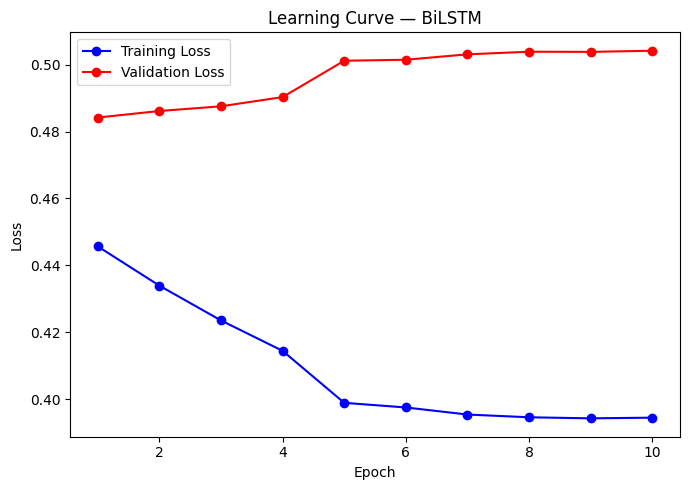

In [11]:
EPOCHS = 10
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
train_losses, val_losses = [], []
best_val_loss = float('inf')
print("Training started...")
print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
    avg_train = total_loss / len(train_loader)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            val_loss += criterion(outputs, y_batch).item()
    avg_val = val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    scheduler.step(avg_val)
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), 'lstm_best.pt')
    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')
plot_learning_curve(
    train_losses,
    val_losses,
    model_name='BiLSTM',
    save_path='lstm_learning_curve.png'
)

## 6. Evaluate on Test Set


  BiLSTM (Test) — Evaluation Report
              precision    recall  f1-score   support

    Negative       0.78      0.78      0.78      9937
    Positive       0.78      0.78      0.78      9957

    accuracy                           0.78     19894
   macro avg       0.78      0.78      0.78     19894
weighted avg       0.78      0.78      0.78     19894

Matthews Correlation Coefficient (MCC): 0.5511
ROC-AUC Score: 0.8544
Macro F1-Score: 0.7756


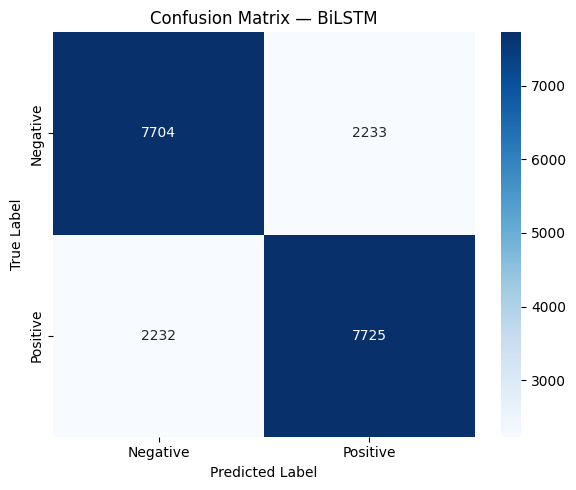

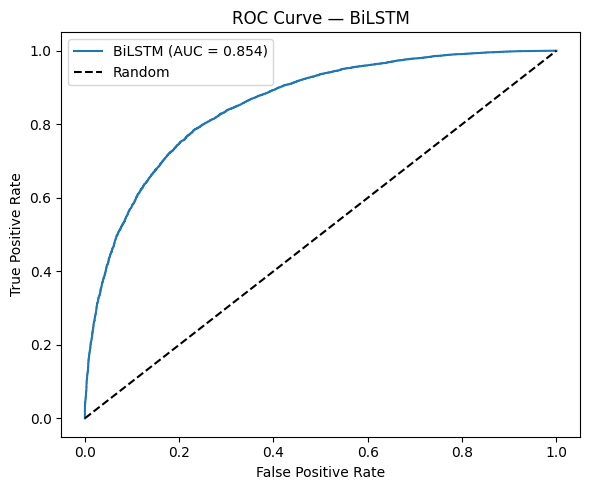

Evaluation complete.


In [12]:
model.load_state_dict(torch.load('lstm_best.pt', map_location=DEVICE))
model.eval()

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)

        logits = model(X_batch)

        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print_metrics(
    all_labels,
    all_preds,
    all_probs,
    model_name='BiLSTM (Test)'
)

plot_confusion_matrix(
    all_labels,
    all_preds,
    model_name='BiLSTM',
    save_path='lstm_confusion_matrix.png'
)

plot_roc_curve(
    all_labels,
    all_probs,
    model_name='BiLSTM',
    save_path='lstm_roc_curve.png'
)

print("Evaluation complete.")

## BiLSTM Model Evaluation

The BiLSTM model was evaluated on the test dataset after training for 5 epochs.

### Results

- Accuracy: 77%
- Precision: 0.76
- Recall: 0.79
- F1-Score: 0.78
- ROC-AUC: 0.8531
- MCC: 0.5418

### Discussion

The BiLSTM model achieved strong performance on the sentiment classification task. The ROC-AUC score of 0.8531 indicates good discrimination between positive and negative sentiments. The confusion matrix shows balanced classification performance across both classes, while the F1-score demonstrates a good balance between precision and recall.

The model correctly classified most reviews and achieved consistent results on the test dataset, making it a competitive deep learning approach for sentiment analysis.